# Evaluación de Goles Esperados

- **xG proyectado:** expectativa ofensiva generada por el modelo antes del partido.
- **xG observado:** calidad acumulada de las ocasiones que realmente se produjeron.
- **Goles observados:** resultado final de esas ocasiones, más sensible a la definición y al rendimiento del portero.

In [46]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"

plt.rcParams.update({
    "figure.facecolor": PAPER,
    "axes.facecolor": PAPER,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11.5,
    "axes.titleweight": "bold",
})


def clean_axes(ax, grid_axis="y", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)


def finish_chart(fig, subtitle, y=0.90):
    fig.text(0.06, y, subtitle, fontsize=10.3, color=MUTED, ha="left")


data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

SOURCE_PATH = DATA_DIR / "predictions.xlsx"
raw_predictions = pd.read_excel(SOURCE_PATH)

required_columns = [
    "match_id", "home_team", "away_team", "match_date", "league",
    "proj_home_xg", "proj_away_xg", "home_xg", "away_xg",
    "home_goals", "away_goals",
]
missing_columns = set(required_columns) - set(raw_predictions.columns)
assert not missing_columns, f"Faltan columnas requeridas: {sorted(missing_columns)}"

predictions = raw_predictions[required_columns].copy()
predictions["match_date"] = pd.to_datetime(predictions["match_date"])
complete_predictions = predictions.dropna().copy()

assert raw_predictions["match_id"].is_unique
assert complete_predictions["match_id"].is_unique
assert complete_predictions[required_columns].notna().all().all()
assert (complete_predictions[["proj_home_xg", "proj_away_xg", "home_xg", "away_xg"]] >= 0).all().all()
assert (complete_predictions[["home_goals", "away_goals"]] >= 0).all().all()

coverage = pd.DataFrame({
    "Indicador": [
        "Partidos en el archivo",
        "Partidos completos",
        "Partidos excluidos por xG faltante",
        "Predicciones equipo-partido",
        "Ligas",
        "Periodo",
    ],
    "Valor": [
        f"{len(raw_predictions):,}",
        f"{len(complete_predictions):,}",
        f"{len(raw_predictions) - len(complete_predictions):,}",
        f"{2 * len(complete_predictions):,}",
        f"{complete_predictions['league'].nunique():,}",
        f"{complete_predictions['match_date'].min():%d/%m/%Y} – {complete_predictions['match_date'].max():%d/%m/%Y}",
    ],
})

display(coverage.set_index("Indicador"))

,Valor
Indicador,
Partidos en el archivo,485
Partidos completos,476
Partidos excluidos por xG faltante,9
Predicciones equipo-partido,952
Ligas,8
Periodo,03/01/2025 – 27/04/2025


## Diez partidos aleatorios antes de mirar los promedios

In [47]:
example_matches = (
    complete_predictions
    .sample(n=10)
    .sort_values(["match_date", "match_id"])
    .copy()
)
example_matches["mean_abs_xg_error"] = (
    (example_matches["proj_home_xg"] - example_matches["home_xg"]).abs()
    + (example_matches["proj_away_xg"] - example_matches["away_xg"]).abs()
) / 2

example_table = pd.DataFrame({
    "Fecha": example_matches["match_date"].dt.strftime("%d/%m/%Y"),
    "Partido": example_matches["home_team"] + " – " + example_matches["away_team"],
    "Liga": example_matches["league"],
    "xG proyectado": example_matches.apply(lambda row: f"{row['proj_home_xg']:.2f} – {row['proj_away_xg']:.2f}", axis=1),
    "xG observado": example_matches.apply(lambda row: f"{row['home_xg']:.2f} – {row['away_xg']:.2f}", axis=1),
    "Marcador": example_matches.apply(lambda row: f"{int(row['home_goals'])} – {int(row['away_goals'])}", axis=1),
    "Error medio xG": example_matches["mean_abs_xg_error"].round(3),
})

display(example_table.reset_index(drop=True))

,Fecha,Partido,Liga,xG proyectado,xG observado,Marcador,Error medio xG
0,11/01/2025,Valladolid – Betis,La Liga,1.07 – 1.53,1.26 – 0.72,1 – 0,0.500
1,01/02/2025,Wolves – Aston Villa,Premier League,1.25 – 1.37,1.68 – 0.44,2 – 0,0.680
2,01/02/2025,Monza – Hellas Verona,Serie A,1.21 – 0.98,0.38 – 0.92,0 – 1,0.445
3,02/02/2025,Betis – Athletic Club,La Liga,1.21 – 1.10,1.18 – 1.48,2 – 2,0.205
4,02/02/2025,Reims – Nantes,Ligue 1,1.23 – 1.36,1.06 – 2.37,1 – 2,0.590
5,15/02/2025,West Ham – Brentford,Premier League,0.99 – 1.49,0.83 – 1.72,0 – 1,0.195
6,16/02/2025,Charleroi – Anderlecht,Belgian First Division A,1.60 – 1.05,0.51 – 0.72,0 – 1,0.710
7,05/04/2025,Barcelona – Betis,La Liga,2.33 – 1.04,1.38 – 0.30,1 – 1,0.845
8,06/04/2025,Go Ahead Eag – Utrecht,Eredivisie,1.50 – 1.10,1.88 – 1.03,2 – 2,0.225
9,24/04/2025,Twente – PSV Eindhoven,Eredivisie,1.25 – 0.12,0.86 – 0.00,1 – 3,0.255


## MAE y RMSE

In [48]:
home_observations = complete_predictions.rename(columns={
    "home_team": "team",
    "proj_home_xg": "predicted_xg",
    "home_xg": "observed_xg",
    "home_goals": "observed_goals",
})[["match_id", "match_date", "league", "team", "predicted_xg", "observed_xg", "observed_goals"]].assign(side="Local")

away_observations = complete_predictions.rename(columns={
    "away_team": "team",
    "proj_away_xg": "predicted_xg",
    "away_xg": "observed_xg",
    "away_goals": "observed_goals",
})[["match_id", "match_date", "league", "team", "predicted_xg", "observed_xg", "observed_goals"]].assign(side="Visitante")

team_observations = pd.concat([home_observations, away_observations], ignore_index=True)


def regression_metrics(observed, estimated):
    return {
        "MAE": mean_absolute_error(observed, estimated),
        "RMSE": np.sqrt(mean_squared_error(observed, estimated)),
        "R²": r2_score(observed, estimated),
    }


metric_specs = [
    ("xG Proyectados → xG Observados", team_observations["observed_xg"], team_observations["predicted_xg"]),
    ("xG Proyectados → Goles", team_observations["observed_goals"], team_observations["predicted_xg"]),
    ("xG Observados → Goles", team_observations["observed_goals"], team_observations["observed_xg"]),
]

metrics = pd.DataFrame(
    [{"Comparación": label, **regression_metrics(observed, estimated)} for label, observed, estimated in metric_specs]
).set_index("Comparación")

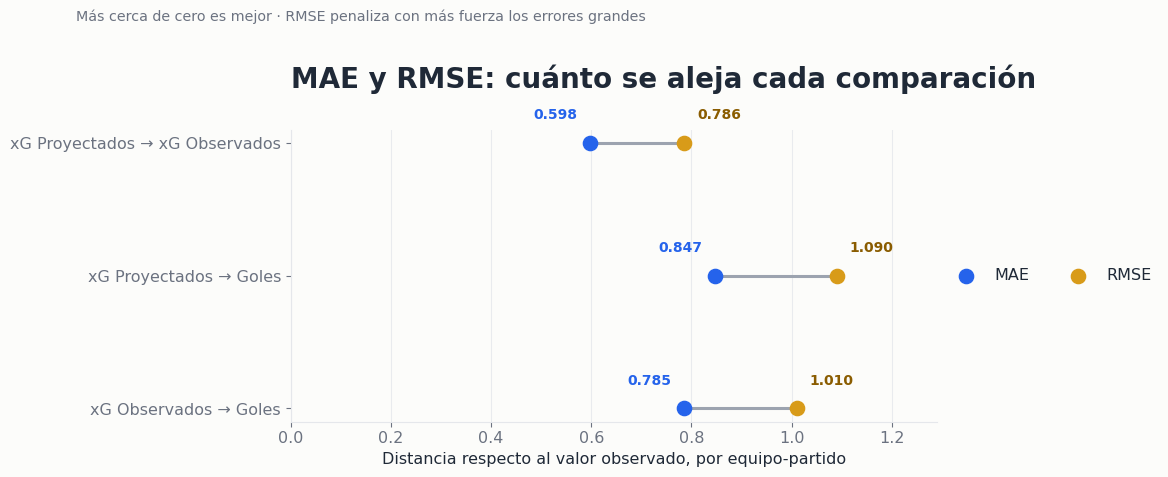

In [49]:
comparison_labels = metrics.index.tolist()
y_positions = np.arange(len(comparison_labels))[::-1]

fig, ax = plt.subplots(figsize=(13.8, 5.2))

for y, label in zip(y_positions, comparison_labels):
    mae = metrics.loc[label, "MAE"]
    rmse = metrics.loc[label, "RMSE"]
    ax.plot([mae, rmse], [y, y], color=GREY, linewidth=2.2, zorder=1)
    ax.scatter(mae, y, s=105, color=BLUE, marker="o", label="MAE" if y == y_positions[0] else None, zorder=2)
    ax.scatter(rmse, y, s=105, color=GOLD, marker="o", label="RMSE" if y == y_positions[0] else None, zorder=2)
    ax.text(mae - 0.025, y + 0.18, f"{mae:.3f}", color=BLUE, ha="right", fontsize=10, fontweight="bold")
    ax.text(rmse + 0.025, y + 0.18, f"{rmse:.3f}", color="#8A5C00", ha="left", fontsize=10, fontweight="bold")

ax.set_yticks(y_positions, comparison_labels)
ax.set_xlim(0, metrics["RMSE"].max() + 0.20)
ax.set_xlabel("Distancia respecto al valor observado, por equipo-partido")
ax.set_title("MAE y RMSE: cuánto se aleja cada comparación", loc="left", fontsize=20, pad=30)
ax.legend(frameon=False, ncol=2, loc="center left", bbox_to_anchor=(1.01, 0.5), borderaxespad=0)
clean_axes(ax, grid_axis="x")

finish_chart(fig, "Más cerca de cero es mejor · RMSE penaliza con más fuerza los errores grandes", y=0.89)
plt.tight_layout(rect=(0, 0, 0.86, 0.84))
plt.show()

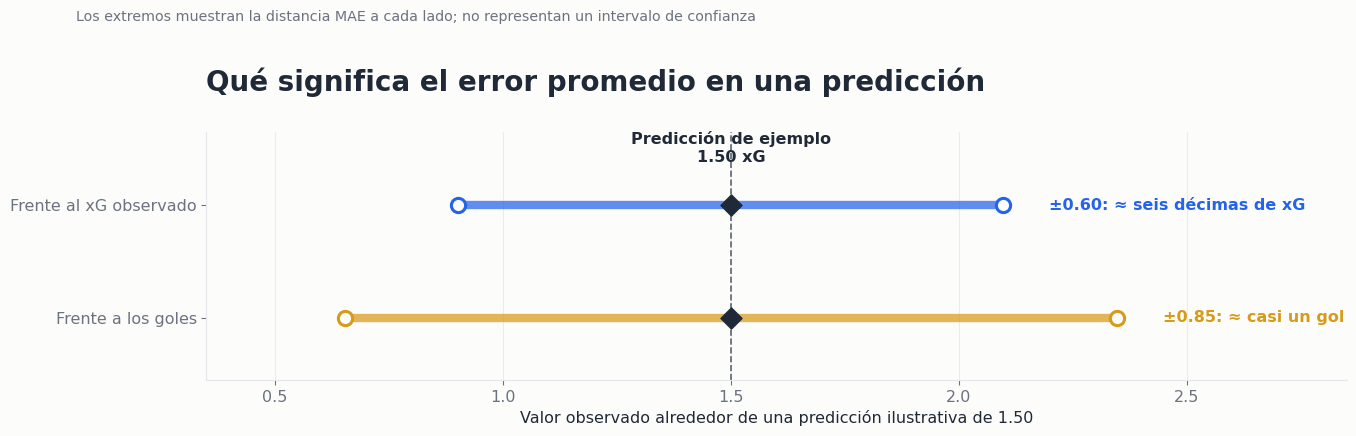

In [50]:
example_prediction = 1.50
model_xg_mae = metrics.loc["xG Proyectados → xG Observados", "MAE"]
model_goal_mae = metrics.loc["xG Proyectados → Goles", "MAE"]

mae_examples = [
    ("Frente al xG observado", model_xg_mae, BLUE, "≈ seis décimas de xG"),
    ("Frente a los goles", model_goal_mae, GOLD, "≈ casi un gol"),
]

fig, ax = plt.subplots(figsize=(13.8, 4.8))
for y, (label, distance, color, plain_text) in zip([1, 0], mae_examples):
    low, high = example_prediction - distance, example_prediction + distance
    ax.plot([low, high], [y, y], color=color, linewidth=6, solid_capstyle="round", alpha=0.72)
    ax.scatter([low, high], [y, y], s=105, facecolor=PAPER, edgecolor=color, linewidth=2.2, zorder=3)
    ax.scatter(example_prediction, y, s=115, color=INK, marker="D", zorder=4)
    ax.text(high + 0.10, y, f"±{distance:.2f}: {plain_text}", va="center", color=color, fontweight="bold")

ax.axvline(example_prediction, color=INK, linestyle="--", linewidth=1.2, alpha=0.7)
ax.text(example_prediction, 1.36, "Predicción de ejemplo\n1.50 xG", ha="center", va="bottom", color=INK, fontweight="bold")
ax.set_yticks([1, 0], [item[0] for item in mae_examples])
ax.set_xlim(0.35, 2.85)
ax.set_ylim(-0.55, 1.65)
ax.set_xlabel("Valor observado alrededor de una predicción ilustrativa de 1.50")
ax.set_title("Qué significa el error promedio en una predicción", loc="left", fontsize=20, pad=30)
clean_axes(ax, grid_axis="x")

finish_chart(fig, "Los extremos muestran la distancia MAE a cada lado; no representan un intervalo de confianza", y=0.88)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

## R²

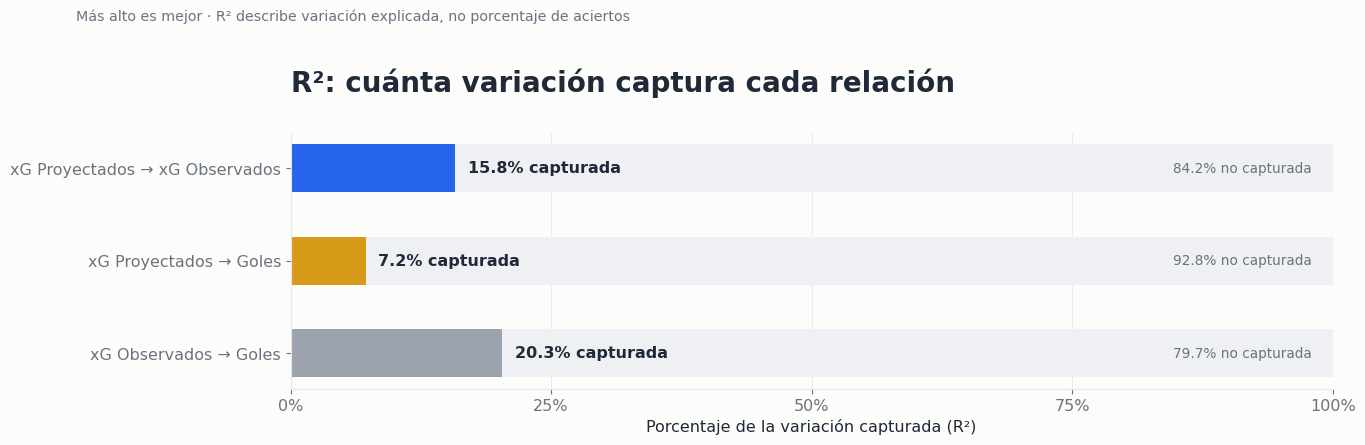

In [51]:
r2_percent = metrics["R²"] * 100
r2_colors = [BLUE, GOLD, GREY]

fig, ax = plt.subplots(figsize=(13.8, 4.9))
ax.barh(y_positions, np.full(len(y_positions), 100), color="#EEF0F3", height=0.52)
bars = ax.barh(y_positions, r2_percent.to_numpy(), color=r2_colors, height=0.52)

for bar, value in zip(bars, r2_percent):
    center_y = bar.get_y() + bar.get_height() / 2
    ax.text(value + 1.2, center_y, f"{value:.1f}% capturada", va="center", fontweight="bold")
    ax.text(98, center_y, f"{100 - value:.1f}% no capturada", va="center", ha="right", color=MUTED, fontsize=9.8)

ax.set_yticks(y_positions, comparison_labels)
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("Porcentaje de la variación capturada (R²)")
ax.set_title("R²: cuánta variación captura cada relación", loc="left", fontsize=20, pad=30)
clean_axes(ax, grid_axis="x")

finish_chart(fig, "Más alto es mejor · R² describe variación explicada, no porcentaje de aciertos", y=0.88)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

## xG observado frente a xG proyectado

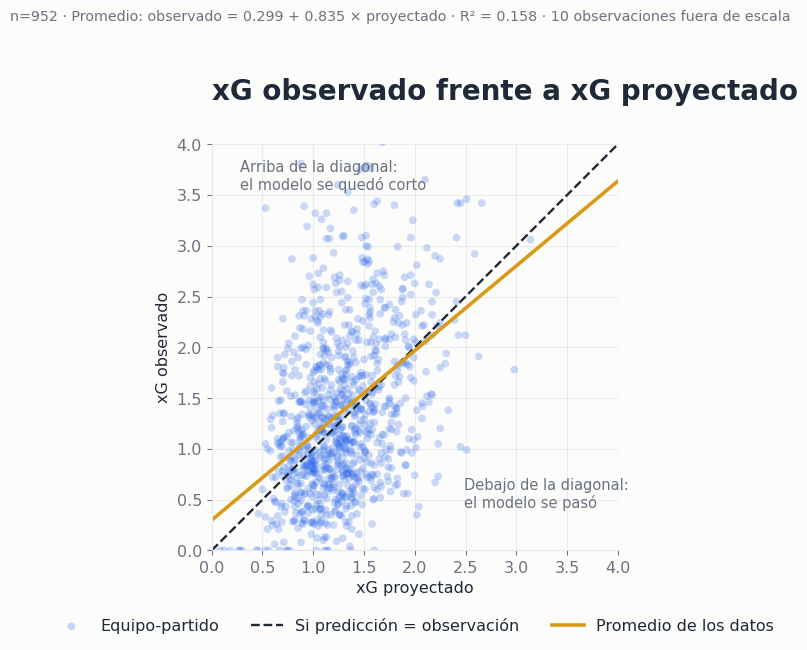

In [52]:
predicted_xg = team_observations["predicted_xg"].to_numpy()
observed_xg = team_observations["observed_xg"].to_numpy()
xg_slope, xg_intercept = np.polyfit(predicted_xg, observed_xg, 1)
xg_r2 = metrics.loc["xG Proyectados → xG Observados", "R²"]

axis_limit = 4.0
out_of_view = int(((predicted_xg > axis_limit) | (observed_xg > axis_limit)).sum())
fit_x = np.linspace(0, axis_limit, 200)

fig, ax = plt.subplots(figsize=(9.2, 8.0))
ax.scatter(predicted_xg, observed_xg, s=31, color=BLUE, alpha=0.24, edgecolors="none", label="Equipo-partido")
ax.plot([0, axis_limit], [0, axis_limit], color=INK, linestyle="--", linewidth=1.7, label="Si predicción = observación")
ax.plot(fit_x, xg_intercept + xg_slope * fit_x, color=GOLD, linewidth=2.6, label="Promedio de los datos")

ax.text(0.28, 3.55, "Arriba de la diagonal:\nel modelo se quedó corto", color=MUTED, fontsize=10.5)
ax.text(2.48, 0.42, "Debajo de la diagonal:\nel modelo se pasó", color=MUTED, fontsize=10.5)

ax.set_xlim(0, axis_limit)
ax.set_ylim(0, axis_limit)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("xG proyectado")
ax.set_ylabel("xG observado")
ax.set_title("xG observado frente a xG proyectado", loc="left", fontsize=20, pad=32)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3)
clean_axes(ax, grid_axis="both")

finish_chart(
    fig,
    f"n={len(team_observations):,} · Promedio: observado = {xg_intercept:.3f} + {xg_slope:.3f} × proyectado · R² = {xg_r2:.3f} · {out_of_view} observaciones fuera de escala",
    y=0.91,
)
plt.tight_layout(rect=(0, 0.08, 1, 0.86))
plt.show()

## Goles frente a xG proyectado

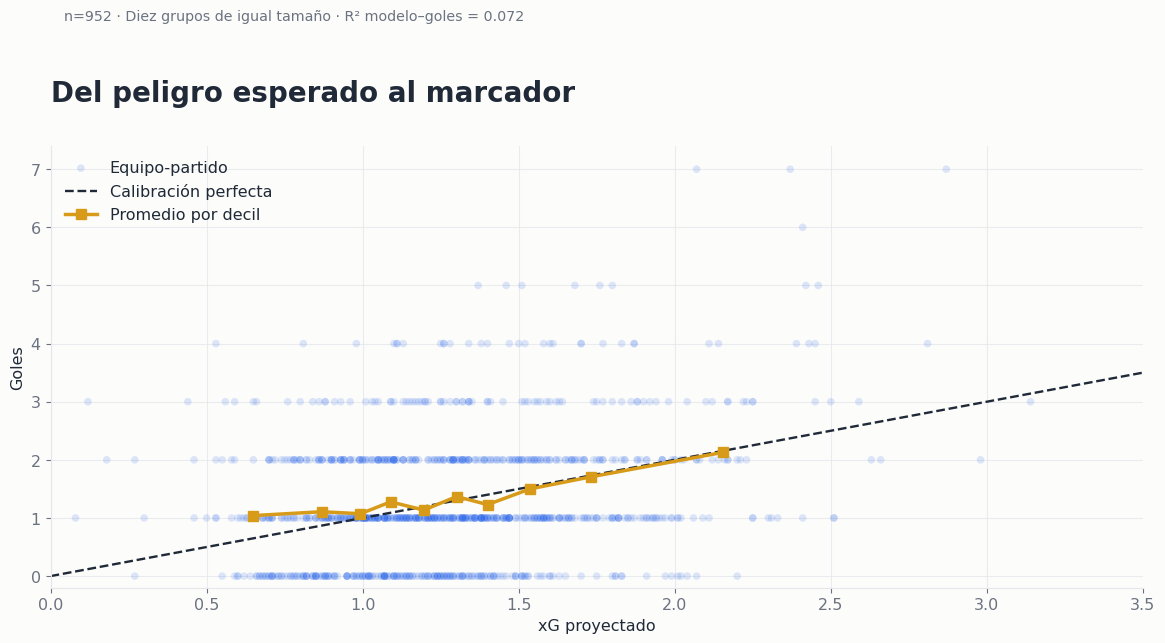

In [55]:
team_observations["goal_calibration_decile"] = pd.qcut(
    team_observations["predicted_xg"], q=10, duplicates="drop"
)
goal_calibration = (
    team_observations
    .groupby("goal_calibration_decile", observed=False)
    .agg(
        mean_predicted_xg=("predicted_xg", "mean"),
        mean_goals=("observed_goals", "mean"),
        observations=("match_id", "size"),
    )
    .reset_index(drop=True)
)

goal_r2 = metrics.loc["xG Proyectados → Goles", "R²"]
x_limit = np.ceil(team_observations["predicted_xg"].max() * 2) / 2
y_limit = int(team_observations["observed_goals"].max()) + 0.4

fig, ax = plt.subplots(figsize=(11.8, 7.0))
ax.scatter(
    team_observations["predicted_xg"],
    team_observations["observed_goals"],
    s=30,
    color=BLUE,
    alpha=0.15,
    edgecolors="none",
    label="Equipo-partido",
)
ax.plot([0, x_limit], [0, x_limit], color=INK, linestyle="--", linewidth=1.7, label="Calibración perfecta")
ax.plot(
    goal_calibration["mean_predicted_xg"],
    goal_calibration["mean_goals"],
    color=GOLD,
    marker="s",
    markersize=7,
    linewidth=2.5,
    label="Promedio por decil",
)

ax.set_xlim(0, x_limit)
ax.set_ylim(-0.2, y_limit)
ax.set_xlabel("xG proyectado")
ax.set_ylabel("Goles")
ax.set_title("Del peligro esperado al marcador", loc="left", fontsize=20, pad=32)
ax.legend(frameon=False, loc="upper left")
clean_axes(ax, grid_axis="both")

finish_chart(fig, f"n={len(team_observations):,} · Diez grupos de igual tamaño · R² modelo–goles = {goal_r2:.3f}", y=0.90)
plt.tight_layout(rect=(0, 0, 1, 0.84))
plt.show()

## Qué nos llevamos

- El modelo se acerca más al **xG observado** que a los goles: MAE de **0.598** frente a **0.847**.
- La comparación modelo–xG alcanza R² **0.158**; frente a goles baja a **0.072**, consistente con el ruido adicional del marcador.
- El propio xG observado tampoco reproduce perfectamente los goles: su MAE es **0.785** y su R² **0.203**. Esta referencia pone en contexto el límite de una predicción prepartido.
- RMSE supera al MAE en las tres comparaciones, señal de que una parte del error proviene de casos grandes y no de una desviación uniforme.
- La pendiente de calibración modelo–xG es menor que 1 y el residuo medio es ligeramente positivo; conviene revisar la compresión de predicciones bajas y altas antes de interpretar solo el promedio.

## Checks de reproducibilidad

- Fuente congelada: `02_data/predictions.xlsx`, hoja `Sheet1`.
- Muestra original: 485 partidos; muestra completa: 476 partidos y 952 observaciones equipo-partido.
- Exclusión: nueve partidos sin xG observado para uno o ambos equipos.
- Ejemplos: diez partidos sin reemplazo con `random_state=42`.
- Métricas: `sklearn.metrics`, con el valor observado como `y_true` y la estimación como `y_pred`.
- Calibración y residuos: diez grupos de igual frecuencia calculados con `pandas.qcut`.
- El notebook no abre conexiones SQL, no utiliza credenciales y no necesita red.